In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

# Lectura del dataset. 
En el dataset original, los nombres de las columnas tienen espacios inecesarios al inicio y al final. Esta celda recupera el dataset y elimina esos espacios incomodos. Si la cadena resultante es vacía, coloca un simbolo "-" para indicar la ausencia de un valor para esa columna

In [2]:
# pd.set_option('display.max_rows', 200)   # show up to 200 rows
df = pd.read_csv("fm2023.csv")

s=df.columns
a=s.tolist()
for i in range(len(a)):
    a[i]=a[i].strip()
df.columns=a
df.columns

Index(['UID', 'Inf', 'Name', 'DoB', 'Nat', 'Division', 'Club', 'Based',
       'Preferred Foot', 'Right Foot', 'Left Foot', 'Position', 'Height',
       'Weight', 'Age', 'Transfer Value', 'Wage', 'AT Apps', 'AT Gls', 'Team',
       'Caps', 'Yth Apps', 'Style', 'Rc Injury', 'Best Role', 'Best Duty',
       'Best Pos', 'Acc', 'Aer', 'Agg', 'Agi', 'Ant', 'Bal', 'Bra', 'Cmd',
       'Com', 'Cmp', 'Cnt', 'Cor', 'Cro', 'Dec', 'Det', 'Dri', 'Ecc', 'Fin',
       'Fir', 'Fla', 'Fre', 'Han', 'Hea', 'Jum', 'Kic', 'Ldr', 'Lon', 'L Th',
       'Mar', 'Nat .1', 'OtB', '1v1', 'Pac', 'Pas', 'Pen', 'Pos', 'Pun', 'Ref',
       'TRO', 'Sta', 'Str', 'Tck', 'Tea', 'Tec', 'Thr', 'Vis', 'Wor'],
      dtype='object')

In [3]:
import numpy as np

def clean_strings(df):
    df = df.copy()
    
    string_cols = df.select_dtypes(include=["object", "string"]).columns
    
    for col in string_cols:
        df[col] = (
            df[col]
            .str.strip()
            .replace("", "-")
        )
    
    return df

In [4]:
df = clean_strings(df)

In [16]:
df.dtypes

UID                         int64
Inf                        object
Name                       object
DoB                        object
Nat                        object
                            ...  
Vis                         int64
Wor                         int64
transfer_value_estimado     int64
price_group                object
notforsale_count           object
Length: 77, dtype: object

# Limpieza

## Conversión de Transfer Value de rangos de precio -> un precio fijo
La columna "Transfer Value" de nuestro dataset contiene rangos de precios a los que los clubes estarían dispuestos a vender a un jugador.
Para trabajar con el valor de transferencia como un número y no un rango, el siguiente par de celdas:
- 1) Recuperan tanto el valor mínimo (min_price) como el máximo (max_price) de cada jugador.
- 2) Crean una nueva columna llamada "transfer_value_estimado" que contiene la siguiente estimación de valor de transferencia:
    $\frac{\text{max\_price} + \text{min\_price}}{2}$ que no es otra cosa más que el punto medio.
    La nueva columna contiene valores numéricos que representan el valor de transferencia estimado en euros (sin abreviaciones).

### Consideraciones
Algunos jugadores poseen un estatus particular respecto a su valor de transferencia. Por un lado, algunos no tienen club, por lo que su valor de transferencia es 0. Por otro lado, algunos jugadores son considerados como clave dentro de sus equipos. Esta consideración hace que los clubes no estén dispuestos a negociar con ningún otro club la venta de tal jugador. Para estos segundos, el juego, en lugar de asignar un rango de precios, le asigna un texto que dice "NotforSale". Para estos casos, y con el objetivo de que todos los jugadores tengan un precio asociado, se les asignó un precio arbitrariamente alto (100 millones de euros) para representar que ninguna oferta satisfará al club.

EL siguiente par de celdas:
- 1) Crean la función que genera la nueva columna
- 2) Aplican la función a nuestro dataset

In [ ]:
inf_price=1000e6
def parse_euro_value(s: str) -> float:
    if(s=="NotforSale"):
        return float(inf_price)

    try:
        i = s.index("-")  
        x = s[i+1:]    
    except:
        x=s
    
    x = x.replace("€", "").strip()

    if x.endswith("K"):
        return float(x[:-1]) * 1e3
    elif x.endswith("M"):
        return float(x[:-1]) * 1e6
    else:
        return float(x)

def range_average(range_str: str) -> int:
    try:
        low, high = range_str.split("-")        
    except:
        low, high = range_str,range_str
        
    low_val = parse_euro_value(low)
    high_val = parse_euro_value(high)

    return int((low_val + high_val) / 2)


def genera_columna_precios(df):
    df["Transfer Value"] = (
    df["Transfer Value"]
        .astype(str)
        .str.replace(" ", "", regex=False)
        .str.replace("€", "", regex=False)
    )
    df["transfer_value_estimado"] = df["Transfer Value"].apply(range_average)
    # df.drop("Transfer Value")
    return df

In [7]:
df=genera_columna_precios(df)

# Crear archivos txt de valores por atributo
Para poder visualizar los tipos de datos e identificar registros "vacios" pero que no son explicitamente un NaN o un Null (por ejemplo, un string = " - "), esta celda crea, para cada atributo, un archivo txt donde escribe en cada linea los distintos valores que se encuentran en todo el dataset para ese atributo.
> **CUIDADO:** Ejecutar esta celda generará 74 archivos .txt

In [ ]:
nombre_carpeta = "valores_posibles_por_atributo"

# Create folder if it doesn't exist
os.makedirs(nombre_carpeta, exist_ok=True)

for col in df.columns:
    values = sorted(df[col].unique())

    with open(f"{nombre_carpeta}/{col}.txt", "w") as f:
        for v in values:
            f.write(str(v) + "\n")

# Gráficas

## Cantidad de jugadores por nacionalidad

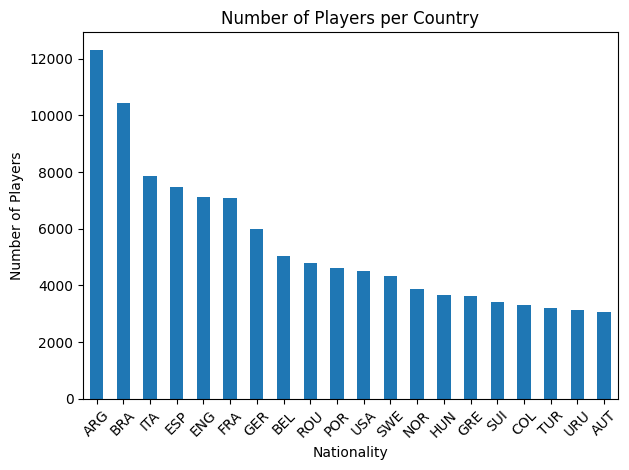

In [9]:
counts = df["Nat"].value_counts()
counts = counts.head(20)
 

plt.figure()
counts.plot(kind="bar")

plt.title("Number of Players per Country")
plt.xlabel("Nationality")
plt.ylabel("Number of Players")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Cantidad de jugadores por posición

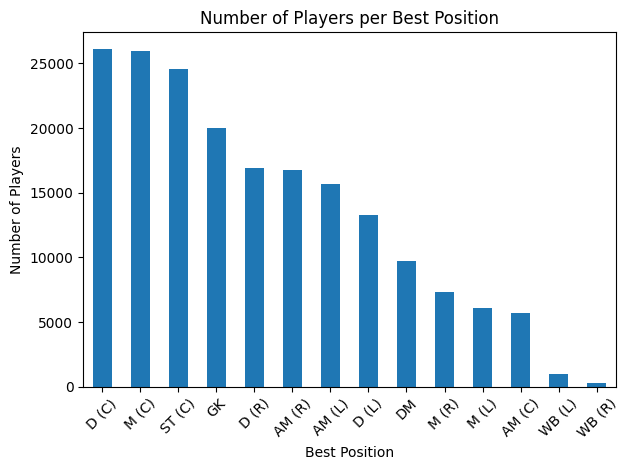

In [10]:
counts = df["Best Pos"].value_counts()
counts = counts.head(50)

plt.figure()
counts.plot(kind="bar")

plt.title("Number of Players per Best Position")
plt.xlabel("Best Position")
plt.ylabel("Number of Players")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Proporción de jugadores con valor de transferencia mayor que un umbral

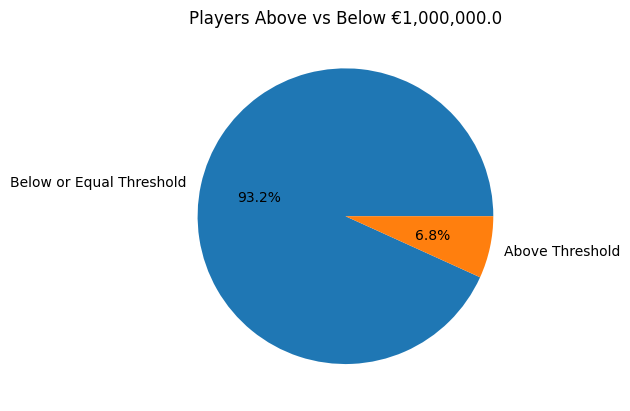

In [11]:
# threshold = 9.4e3 # este separa al dataset en 50% y 50%
threshold = 1e6

df["price_group"] = np.where(
    df["transfer_value_estimado"] > threshold,
    "Above Threshold",
    "Below or Equal Threshold"
)

counts = df["price_group"].value_counts()

plt.figure()
plt.pie(counts, labels=counts.index, autopct="%1.1f%%")
plt.title(f"Players Above vs Below €{threshold:,}")
plt.show()

## Cantidad de jugadores por edad

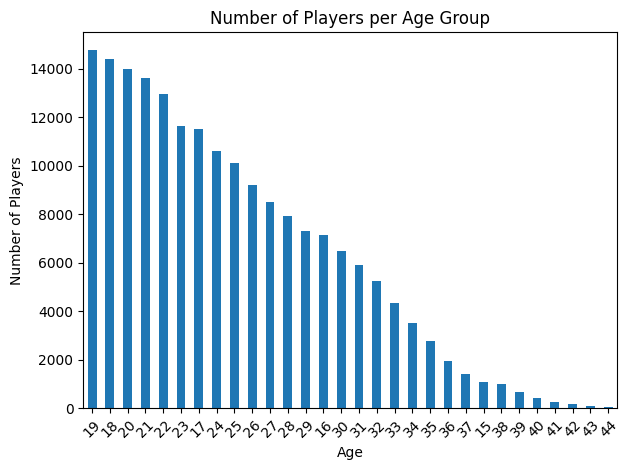

In [12]:
counts = df["Age"].value_counts()
counts = counts.head(30)
 

plt.figure()
counts.plot(kind="bar")

plt.title("Number of Players per Age Group")
plt.xlabel("Age")
plt.ylabel("Number of Players")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Cantidad de jugadores por estilo de juego

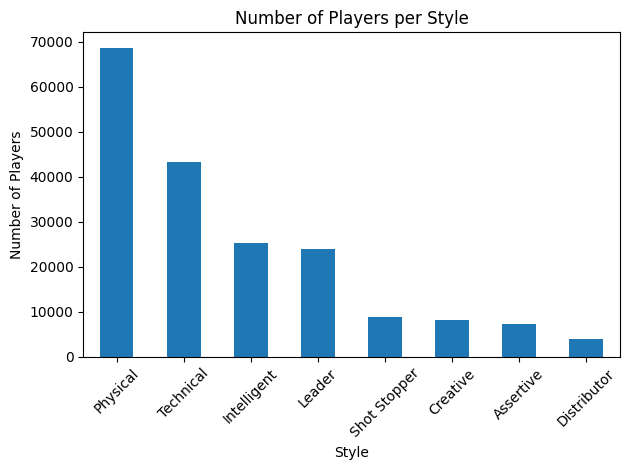

In [ ]:
counts = df["Style"].value_counts()
counts = counts.head(20)
 
plt.figure()
counts.plot(kind="bar")

plt.title("Number of Players per Style")
plt.xlabel("Style")
plt.ylabel("Number of Players")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Jugadores not for sale
Algunos jugadores tienen en su valor de transferencia la frase "NotforSale" que indica que el club con el que tiene contrato no esta dispuesto a negociar la salida del jugador. Para representar este caso en la columna transfer_value_estimado, se colocó un precio fijo llamano inf_price que es igual a 100 millones de euros. Este alto costo representa esa indisposición de los equipos a vender a tal jugador.

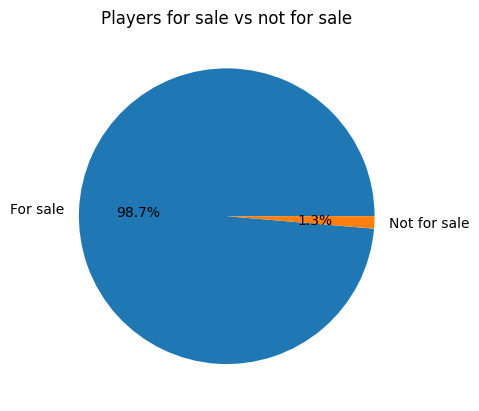

In [14]:

# threshold = 9.4e3
threshold = inf_price

df["notforsale_count"] = np.where(
    df["transfer_value_estimado"] >= threshold,
    "Not for sale",
    "For sale"
)

counts = df["notforsale_count"].value_counts()

plt.figure()
plt.pie(counts, labels=counts.index, autopct="%1.1f%%")
plt.title(f"Players for sale vs not for sale")
plt.show()

## Cuantos jugadores tienen al menos 1 columna con valor vació ("-")

In [ ]:
def count_missing_at_least_one(df, columns=None):
    """
    Cuenta cuantos renglones del dataframe tienen al menos un "-" en alguna de las columnas especificadas
    """
    if columns is None:
        columns = df.columns
    
    return (df[columns] == "-").any(axis=1).sum()